In [43]:
import pandas as pd

df = pd.read_csv("IS8_Business_Employment_Demography.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28400 entries, 0 to 28399
Data columns (total 58 columns):
 #   Column                                                                                                                                               Non-Null Count  Dtype  
---  ------                                                                                                                                               --------------  -----  
 0   YEAR                                                                                                                                                 28400 non-null  int64  
 1   GEOGRAPHY_CODE                                                                                                                                       28400 non-null  object 
 2   GEOGRAPHY_NAME                                                                                                                                       28400 non-null  object 
 

In [45]:
variaveis = df.columns[:56]

result = df.groupby("combined_region")[variaveis].count()

result.to_excel("count_per_region.xlsx")

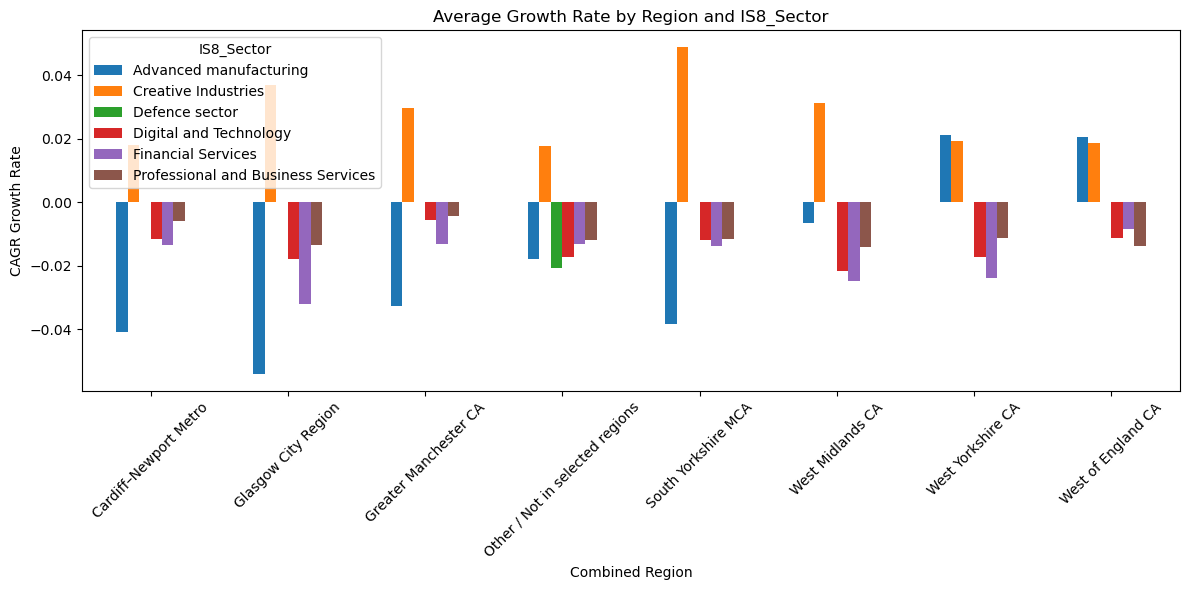

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sum_vars = [
    "OBS_Value_Business",
    "OBS_Value_Employment",
    "Count of active enterprises (control rounded to base 5)",
    "Count of births of new enterprises (control rounded to base 5)",
    "Count of deaths of enterprises (control rounded to base 5)",
    "Count of high growth enterprises (control rounded to base 5)",
    "Count of 19+ Further Education and Skills Learner Achievements (qualifications)",
    "Total FDI international investment position abroad at end period (£ million)",
    "Total FDI international investment position in the UK at end period (£ million)",
    "Total UK public-funded gross regional capital and non-capital expenditure on research and development (£ million)",
    "Total value of UK exports (£ million)"
]

mean_vars = [
    "% living in an area that has a devolution deal with a directly elected mayor ",
    "19+ further education and skills participation (per 100,000 population)",
    "Age-standardised mortality rate for those aged under 75 (per 100,000 population)",
    "Apprenticeships achieved by adults aged 16+ based on home address (per 100,000 population)",
    "Apprenticeships started by adults aged 16+ based on home address (per 100,000 population)",
    "Average travel time in minutes to reach nearest large employment centre (500 to 4999 jobs available), by car (minutes)",
    "Average travel time in minutes to reach nearest large employment centre (500 to 4999 jobs available), by cycle (minutes)",
    "Average travel time in minutes to reach nearest large employment centre (500 to 4999 jobs available), by public transport or walking (minutes)",
    "Employment rate, aged 16 to 64 years (%)",
    "Female Healthy Life Expectancy (years)",
    "Male Healthy Life Expectancy (years)",
    "Gross Value Added (GVA) per hour worked (£)",
    "Gross disposable household income, per head (£)",
    "Gross median weekly pay (£)",
    "Homicide Offences (per million population)",
    "Mean anxiety yesterday scored 0 (not at all) - 10 (completely)",
    "Mean feeling things done in life are worthwhile scored 0 (not at all) - 10 (completely)",
    "Mean happiness yesterday scored 0 (not at all) - 10 (completely)",
    "Mean satisfaction with your life nowadays scored 0 (not at all) - 10 (completely)",
    "Modelled unemployment rate, aged 16 years and over (%)",
    "Net additions per 1,000 stock",
    "Percentage of 4G coverage by at least one mobile network operator (%)",
    "Percentage of 5-year olds at 'expected level' in communication and language early learning goals (%)",
    "Percentage of 5-year olds at 'expected level' in literacy early learning goals (%)",
    "Percentage of 5-year olds at 'expected level' in maths early learning goals (%)",
    "Percentage of adults that currently smoke cigarettes (%)",
    "Percentage of persistent absences (10% or more missed) eligible for free school meals in the past 6 years (%)",
    "Percentage of persistent absences (10% or more missed) for all pupils (%)",
    "Percentage of persistent absences (10% or more missed) for pupils who are looked after continuously for at least 12 months by local authorities (%)",
    "Percentage of premises with gigabit-capable broadband (%)",
    "Percentage of pupils in state-funded schools meeting the expected standard in reading, writing and maths at the end of key stage 2 (%)",
    "Percentage of schools rated good or outstanding by Ofsted (%)",
    "Percentage of young people achieving GCSEs (and equivalent qualifications) in English and maths by age 19 (%)",
    "Proportion of adults living with obesity, aged 18 years and over (%)",
    "Proportion of cancers diagnosed at stages 1 and 2 (%)",
    "Proportion of children living with obesity at Year 6 age (%)",
    "Proportion of children living with obesity at reception age (%)",
    "Proportion of the population aged 16 to 64 with NVQ3+ qualification (%)",
    "Proportion of the population aged 16-64 with NVQ3+ qualification (%)"
]

first_vars = [
    "YEAR",
    "GEOGRAPHY_CODE",
    "GEOGRAPHY_NAME",
    "IS8_SECTOR",
    "FRONTIER_SECTOR"
]


agg_dict = {v: "sum" for v in sum_vars}
agg_dict.update({v: "mean" for v in mean_vars})
agg_dict.update({v: "first" for v in first_vars})

df_region = df.groupby("combined_region").agg(agg_dict).reset_index()


df_wide = df.pivot_table(
    index=["combined_region", "IS8_SECTOR"],
    columns="YEAR",
    values="OBS_Value_Business",
    aggfunc="sum"  
).reset_index()


df_wide["growth_rate"] = np.where(
    df_wide[2022] == 0,  # proteção contra divisão por zero
    np.nan,
    (df_wide[2024] / df_wide[2022])**(1/3) - 1
)

#plot

growth_plot = df_wide.pivot(index="combined_region", columns="IS8_SECTOR", values="growth_rate")

ax = growth_plot.plot(kind="bar", figsize=(12,6))
ax.set_xlabel("Combined Region")
ax.set_ylabel("CAGR Growth Rate")
ax.set_title("Average Growth Rate by Region and IS8_Sector")
plt.legend(title="IS8_Sector")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df_region.to_excel("regional_summary.xlsx", index=False)
df_wide.to_excel("growth_rate_by_region_sector.xlsx", index=False)

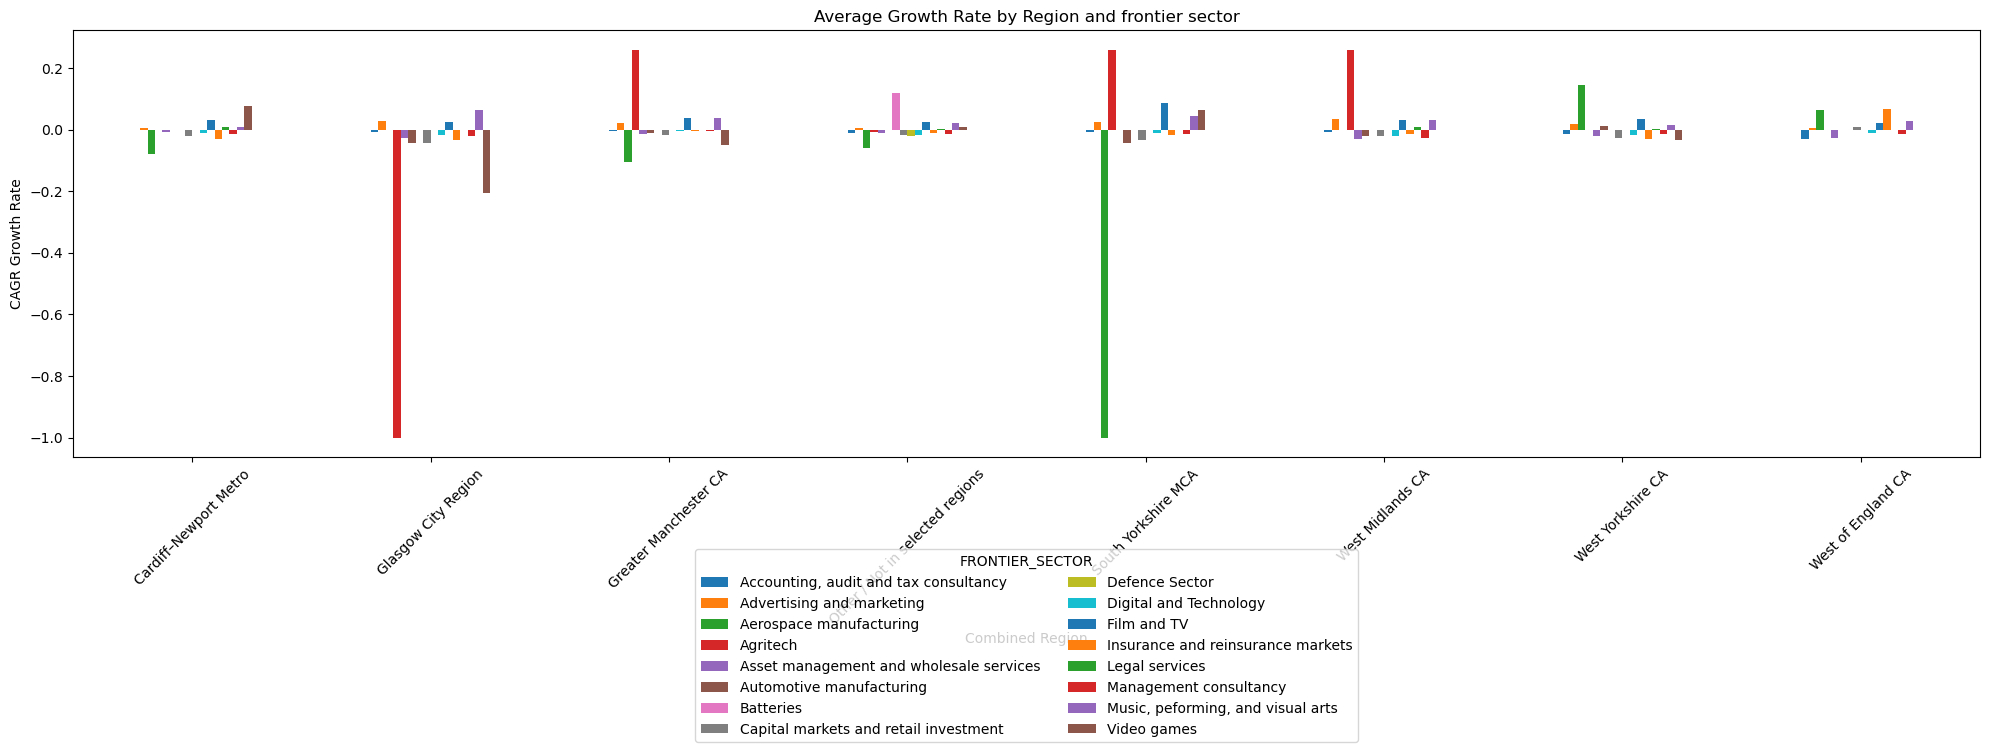

In [59]:
df_wide = df.pivot_table(
    index=["combined_region", "FRONTIER_SECTOR"],
    columns="YEAR",
    values="OBS_Value_Business",
    aggfunc="sum"  
).reset_index()


df_wide["growth_rate"] = np.where(
    df_wide[2022] == 0,  # proteção contra divisão por zero
    np.nan,
    (df_wide[2024] / df_wide[2022])**(1/3) - 1
)

#plot

growth_plot = df_wide.pivot(index="combined_region", columns="FRONTIER_SECTOR", values="growth_rate")

ax = growth_plot.plot(kind="bar", figsize=(20,8))
ax.set_xlabel("Combined Region")
ax.set_ylabel("CAGR Growth Rate")
ax.set_title("Average Growth Rate by Region and frontier sector")
plt.legend(title="Frontier Sector")
plt.xticks(rotation=45)

plt.legend(title="FRONTIER_SECTOR",
           loc='upper center',          
           bbox_to_anchor=(0.5, -0.2), 
           ncol=2)                      

plt.tight_layout()
plt.show()

df_region.to_excel("regional_summary.xlsx", index=False)
df_wide.to_excel("growth_rate_by_region_sector.xlsx", index=False)

In [14]:
crosstab_IS8_sector = df.groupby(["combined_region", "IS8_SECTOR"])["OBS_Value_Business"].sum().sort_values(ascending=False)
crosstab_Frontier = df.groupby(["combined_region", "FRONTIER_SECTOR"])["OBS_Value_Business"].sum().sort_values(ascending=False)

In [57]:
crosstab_IS8_sector.to_excel("crosstab_IS8_sector.xlsx")
crosstab_Frontier.to_excel("crosstab_Frontier.xlsx")

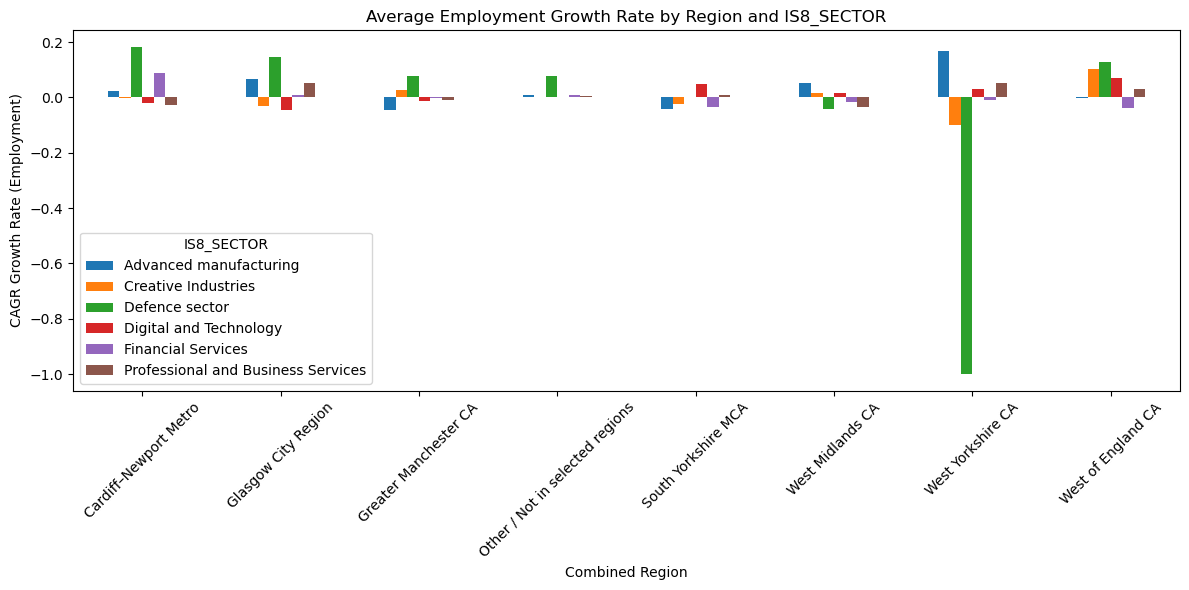

In [53]:
# Employment 
df_wide_v2 = df.pivot_table(
    index=["combined_region", "IS8_SECTOR"],
    columns="YEAR",
    values="OBS_Value_Employment",
    aggfunc="sum"  
).reset_index()


df_wide_v2["growth_rate_v2"] = np.where(
    df_wide_v2[2022] == 0,
    np.nan,
    (df_wide_v2[2024] / df_wide_v2[2022])**(1/3) - 1
)


growth_plot_v2 = df_wide_v2.pivot(index="combined_region", columns="IS8_SECTOR", values="growth_rate_v2")

ax = growth_plot_v2.plot(kind="bar", figsize=(12,6))
ax.set_xlabel("Combined Region")
ax.set_ylabel("CAGR Growth Rate (Employment)")
ax.set_title("Average Employment Growth Rate by Region and IS8_SECTOR")
plt.legend(title="IS8_SECTOR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

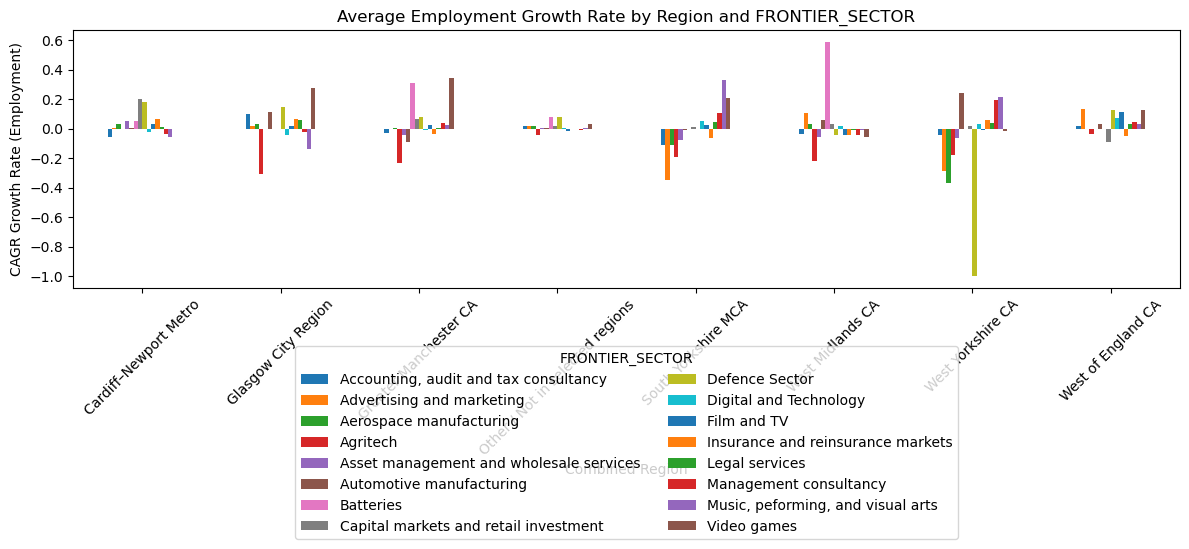

In [56]:
# Employment 
df_wide_v2 = df.pivot_table(
    index=["combined_region", "FRONTIER_SECTOR"],
    columns="YEAR",
    values="OBS_Value_Employment",
    aggfunc="sum"  
).reset_index()


df_wide_v2["growth_rate_v2"] = np.where(
    df_wide_v2[2022] == 0,
    np.nan,
    (df_wide_v2[2024] / df_wide_v2[2022])**(1/3) - 1
)


growth_plot_v2 = df_wide_v2.pivot(index="combined_region", columns="FRONTIER_SECTOR", values="growth_rate_v2")

ax = growth_plot_v2.plot(kind="bar", figsize=(12,6))
ax.set_xlabel("Combined Region")
ax.set_ylabel("CAGR Growth Rate (Employment)")
ax.set_title("Average Employment Growth Rate by Region and FRONTIER_SECTOR")
plt.xticks(rotation=45)

plt.legend(title="FRONTIER_SECTOR",
           loc='upper center',          # centraliza horizontalmente
           bbox_to_anchor=(0.5, -0.2), # posição abaixo do gráfico
           ncol=2)                      # 2 colunas

plt.tight_layout()
plt.show()